# One-word Sample

In [1]:
import numpy as np
import cv2
import copy
import math

def rotate_vector(x, y, xc, yc, angle=0.0): # https://en.wikipedia.org/wiki/Rotation_matrix
    if angle%360 != 0:
        theta = (-1) * angle * math.pi / 180.0
        x_out = (x-xc)*math.cos(theta) - (y-yc)*math.sin(theta) + xc
        y_out = (x-xc)*math.sin(theta) + (y-yc)*math.cos(theta) + yc
        return [x_out, y_out]
    else:
        return [x, y]

def extract_object_coordinates(img, only_calculate_min_xy=False):
    x_min, y_min, x_max, y_max = float('inf'), float('inf'), float('-inf'), float('-inf')
    coords_raw = {}
    c_max = float('-inf')
    for y in range(len(img)):
        for x in range(len(img[0])):
            if img[y][x].max() > 0:
                x_min = min(x_min, x-1) # 1 margin for bbox
                y_min = min(y_min, y-1) # 1 margin for bbox
                x_max = max(x_max, x+1) # 1 margin for bbox
                y_max = max(y_max, y+1) # 1 margin for bbox
                
                if not only_calculate_min_xy:
                    coords_raw[(y,x)] = copy.deepcopy(img[y][x])
                    c_max = max(c_max, max(img[y][x]))

    return (x_min, y_min, x_max, y_max), coords_raw, c_max
                
def generate_text_pixels(
    text,
    fontFace = [
        cv2.FONT_HERSHEY_SIMPLEX,
        cv2.FONT_HERSHEY_PLAIN,
        cv2.FONT_HERSHEY_DUPLEX,
        cv2.FONT_HERSHEY_COMPLEX,
        cv2.FONT_HERSHEY_TRIPLEX,
        cv2.FONT_HERSHEY_COMPLEX_SMALL,
        cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,
        cv2.FONT_HERSHEY_SCRIPT_COMPLEX,
        cv2.FONT_ITALIC,
    ][0],
    fontScale = 1,
    thickness = 1,
    lineType = [cv2.FILLED, cv2.LINE_4, cv2.LINE_8, cv2.LINE_AA][0], # https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html#gaf076ef45de481ac96e0ab3dc2c29a777
    angle = 0, # rotate text
    # angle = +45, # rotation angle
    edge_style = False,
    rgb_clamp = [1.0, 1.0, 1.0],
    # rgb_clamp = [9.0, 9.0, 1.0],
    clamp_func = lambda x, clamp=1.0: max(min(x/clamp, 1.0), 0.0),
    draw_initial_bbox = False, # only debuggin purpose
):

    #--- get text size --------------------------
    (w_text, h_text), _ = cv2.getTextSize(text, fontFace, fontScale, thickness) # (w_text, h_text), baseline

    #--- create blank image ------------------------
    wh_img = math.ceil(math.sqrt((w_text + 2)**2 + (h_text + 2)**2)) + thickness
    img = np.full((wh_img, wh_img, 3), 255*(edge_style), np.uint8) # initialize with black board

    #--- create initial bouding box -------------------
    w_rect, h_rect = w_text, h_text + 2
    # x0, y0 = 0, 0
    x0, y0 = math.ceil(0.5*(wh_img - w_rect)), math.ceil(0.5*(wh_img - h_rect))
    x1, y1 = x0 + w_rect - 1, y0 + h_rect - 1
    if draw_initial_bbox: # only debugging purpose
        cv2.rectangle(img, (x0, y0), (x1, y1), (0,255,0), thickness=1) # rectangle

    #--- draw text on image -------------------
    fontColor = (255*(not edge_style), 255*(not edge_style), 255*(not edge_style)) # white
    org = (x0, y0 + h_text) # Text origin: bottom left corner point
    cv2.putText(img, text, org, fontFace, fontScale, fontColor, thickness, lineType, bottomLeftOrigin=False)

    #--- edge style font ---------------------
    if edge_style:
        img = cv2.Canny(img, 50, 200, apertureSize=5, L2gradient=False) # edge detection
        img = np.expand_dims(img, axis=-1) # convert into RGB format
        img = np.repeat(img, repeats=3, axis=-1) # convert into RGB format

    #--- calculate rotated bounding box -----------
    (x_min0, y_min0, x_max0, y_max0), _, _ = extract_object_coordinates(img, only_calculate_min_xy=True)
    xc, yc = 0.5*wh_img, 0.5*wh_img

    rbox_ = [ # clock-wise direction
        rotate_vector(x_min0, y_min0, xc, yc, angle=angle), # top left
        rotate_vector(x_max0, y_min0, xc, yc, angle=angle), # top right
        rotate_vector(x_max0, y_max0, xc, yc, angle=angle), # bottom right
        rotate_vector(x_min0, y_max0, xc, yc, angle=angle), # bottom left
    ]

    #--- rotate image: https://stackoverflow.com/questions/9041681/opencv-python-rotate-image-by-x-degrees-around-specific-point
    if angle%360 != 0:
        image_center = tuple(np.array(img.shape[1::-1]) / 2)
        rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
        img = cv2.warpAffine(img, rot_mat, img.shape[1::-1], flags=cv2.INTER_LINEAR)

    #--- extract coordinates --------------
    (x_min, y_min, x_max, y_max), coords_raw, c_max = extract_object_coordinates(img, only_calculate_min_xy=False)

    #--- chop image ---
    coords = {}
    for (y,x), (r,g,b) in coords_raw.items():
    #     coords[(y - y_min, x - x_min)] = [r, g, b]
        coords[(y - y_min, x - x_min)] = [
            255 - int(c_max*clamp_func(r/c_max, rgb_clamp[0])), # 255: invert color
            255 - int(c_max*clamp_func(g/c_max, rgb_clamp[1])), # 255: invert color
            255 - int(c_max*clamp_func(b/c_max, rgb_clamp[2])), # 255: invert color
        ]

    bbox = [0, 0, x_max - x_min, y_max - y_min]
    rbox = [[x - x_min, y - y_min] for x, y in rbox_]

    return coords, bbox, rbox

# Draw Bbox

In [2]:
import cv2

def draw_bboxes(img, true_bboxes=[], pred_bboxes=[], box_format='xywh', true_box_color=(0,255,0), pred_box_color=(255,0,0), thickness=1):
    img2 = img.copy()

    for bboxes, color in [(true_bboxes, true_box_color), (pred_bboxes, pred_box_color)]:
        for a, b, c, d in bboxes:
            if box_format == 'xywh':
                xc, yc, w, h = a, b, c, d
                x0, y0, x1, y1 = int(xc - 0.5*w), int(yc - 0.5*h), int(xc + 0.5*w), int(yc + 0.5*h)
            elif box_format == 'xyxy':
                x0, y0, x1, y1 = a, b, c, d
            else:
                raise(f'Brad error: no such box_format = {box_format}')

            img2 = cv2.rectangle(img2, (x0, y0), (x1, y1), color=color, thickness=thickness)

    return img2

# Draw Rbox

In [3]:
import math

def rotate_vector(x, y, xc=0, yc=0, angle=0.0): # https://en.wikipedia.org/wiki/Rotation_matrix
    """version: 2023-12-17"""
    if angle%360 != 0:
        theta = (-1) * angle * math.pi / 180.0
        x_out = (x-xc)*math.cos(theta) - (y-yc)*math.sin(theta) + xc
        y_out = (x-xc)*math.sin(theta) + (y-yc)*math.cos(theta) + yc
        return [x_out, y_out]
    else:
        return [x, y]

In [4]:
import cv2

def draw_rboxes(img, true_rboxes=[], true_angles=None, pred_rboxes=[], pred_angles=None, box_format='xywh', true_box_color=(0,255,0), pred_box_color=(255,0,0), thickness=1):
    img2 = img.copy()

    for rboxes, angles, color in [(true_rboxes, true_angles, true_box_color), (pred_rboxes, pred_angles, pred_box_color)]:
        rboxes_new = []
        for rbox, angle in zip(rboxes, angles) if angles is not None else zip(rboxes, [None]*len(rboxes)):
            if box_format == 'xywh':
                xc, yc, w, h = rbox
                rbox_new = []
                for x, y in [
                    [int(xc - 0.5*w), int(yc - 0.5*h)],
                    [int(xc + 0.5*w), int(yc - 0.5*h)],
                    [int(xc + 0.5*w), int(yc + 0.5*h)],
                    [int(xc - 0.5*w), int(yc + 0.5*h)],
                ]:
                    rbox_new.append(rotate_vector(x, y, xc=xc, yc=yc, angle=angle))
            elif box_format == 'xyxy':
                rbox_new = rbox
            else:
                raise(f'Brad error: no such box_format = {box_format}')
            
            rboxes_new.append(rbox_new)

        cv2.polylines(img2, [np.array(rbox,np.int32) for rbox in rboxes_new], isClosed=True, color=color, thickness=thickness)

    return img2

[0, 0, 73, 42] [[0.1473729346409698, 21.493229805697624], [65.92585638965457, -2.4481802270991864], [73.79231968614494, 19.164750050976707], [8.01383623113135, 43.10616008377352]]


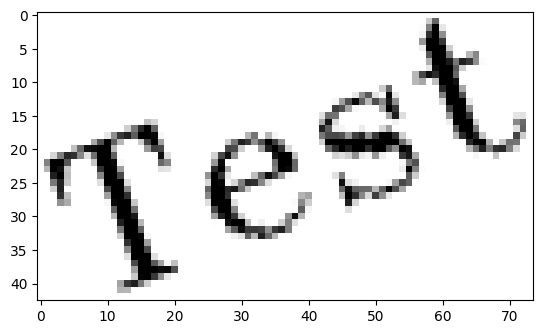

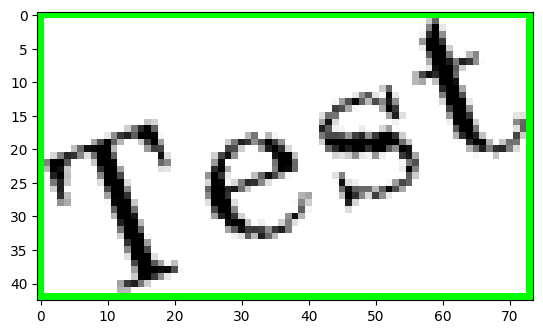

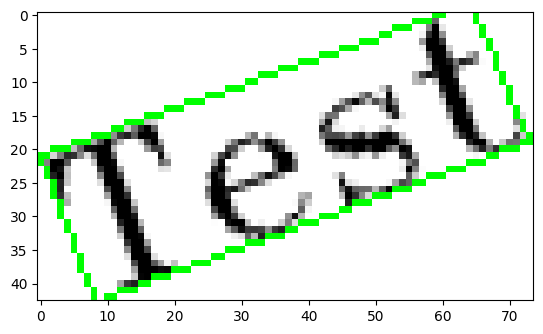

In [5]:
if __name__=='__main__':
    import matplotlib.pyplot as plt
    
    text = 'Test'

    coords, bbox, rbox = generate_text_pixels(
        text,
        fontFace = [
            cv2.FONT_HERSHEY_SIMPLEX,
            cv2.FONT_HERSHEY_PLAIN,
            cv2.FONT_HERSHEY_DUPLEX,
            cv2.FONT_HERSHEY_COMPLEX,
            cv2.FONT_HERSHEY_TRIPLEX,
            cv2.FONT_HERSHEY_COMPLEX_SMALL,
            cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,
            cv2.FONT_HERSHEY_SCRIPT_COMPLEX,
            cv2.FONT_ITALIC,
        ][4],
        fontScale = 1,
        thickness = 1,
        lineType = [cv2.FILLED, cv2.LINE_4, cv2.LINE_8, cv2.LINE_AA][0], # https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html#gaf076ef45de481ac96e0ab3dc2c29a777
        angle = 20, # rotate text
        # angle = +45, # rotation angle
        edge_style = False,
    )
    print(bbox, rbox)

    img = np.full((bbox[3]+1, bbox[2]+1, 3), 255, np.uint8) # white board
    for (y,x), rgb in coords.items():
        img[y][x] = rgb

    img2 = draw_bboxes(img, true_bboxes=[bbox], box_format='xyxy')
    img3 = draw_rboxes(img, true_rboxes=[rbox], box_format='xyxy')
    #--- show image ----
    plt.imshow(img)
    plt.show()
    plt.imshow(img2)
    plt.show()
    plt.imshow(img3)
    plt.show()

# Scene Text Detection
- https://github.com/HCIILAB/Scene-Text-Detection#213-regression-methods

- Algorithm for finding all potential carpet locations in a room with wall

In [6]:
from collections import deque

def find_carpet_locations(room, carpet_h, carpet_w, symbol_wall): # Upaded 2023-11-25 by Brad Kim; time complexity = O(m*n); space complexity = O(m*n)
    """
    > Inputs:
    room = [ # m x n matrix
        ['O','O','O','O','O'],
        ['O','O','O','O','X'],
        ['O','O','O','X','X'],
        ['O','O','X','X','X'],
        ['O','X','X','X','X'],
    ]
    carpet_h = 3 # carpet height
    carpet_w = 2 # carpet width
    symbol_wall = 'X'

    > Outputs:
    locations: # m x n matrix
    rcnts: # m x n matrix
    mques: # list of n monotonic queues
    """

    assert carpet_h > 0 and carpet_w > 0

    m, n = len(room), len(room[0]) # whole room area
    m_, n_ = m - (carpet_h - 1), n - (carpet_w - 1) # potential area for carpet in the room

    rcnts = [[0]*(n+1) for _ in range(m)] # counts in reverse row order
    mques = [deque([]) for _ in range(n_)] # monotonic queue

    locations = []
    for i in range(m-1, -1, -1):
        for j in range(n-1, -1, -1):
            #--- counts in reverse row order ----
            if room[i][j] != symbol_wall:
                rcnts[i][j] = rcnts[i][j+1] + 1

            #--- monotonic queue ----------------
            if j < n_:
                while mques[j] and rcnts[i][j] <= mques[j][0][0]:
                    mques[j].popleft()

                mques[j].appendleft([rcnts[i][j], i])

                while i + carpet_h - 1 < mques[j][-1][-1]: # drop old data points if they are beyond carpet height
                    mques[j].pop()

                if (i < m_) and (mques[j][-1][0] >= carpet_w):
                    locations.append([i,j])

    out = {'locations':locations[::-1], 'rcnts':rcnts, 'mques':mques}

    return out

if __name__=='__main__':
    # room = [
    #     ['O','O','O','O','O'],
    #     ['O','O','O','O','O'],
    #     ['O','O','O','O','O'],
    #     ['O','O','O','O','O'],
    #     ['O','O','O','O','O'],
    # ]
    # room = [
    #     ['O','O','O','O','O'],
    #     ['O','O','O','O','O'],
    #     ['O','O','O','X','O'],
    #     ['O','X','O','O','O'],
    #     ['O','O','O','O','O'],
    # ]
    room = [
        ['O','O','O','O','O'],
        ['O','O','O','O','X'],
        ['O','O','O','X','X'],
        ['O','O','X','X','X'],
        ['O','X','X','X','X'],
    ]

    carpet_h = 3
    carpet_w = 2
    symbol_wall = 'X'

    out = find_carpet_locations(room, carpet_h, carpet_w, symbol_wall)
        
    print('rcnts =', out['rcnts'])
    print('mques =', out['mques'])
    print('locations =', out['locations'])
    print('len(locations) =', len(out['locations']))

rcnts = [[5, 4, 3, 2, 1, 0], [4, 3, 2, 1, 0, 0], [3, 2, 1, 0, 0, 0], [2, 1, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0]]
mques = [deque([[5, 0], [4, 1], [3, 2]]), deque([[4, 0], [3, 1], [2, 2]]), deque([[3, 0], [2, 1], [1, 2]]), deque([[2, 0], [1, 1], [0, 2]])]
locations = [[0, 0], [0, 1], [1, 0]]
len(locations) = 3


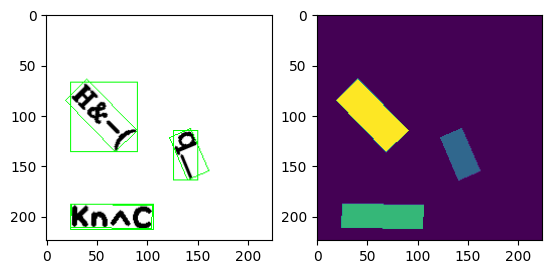

In [15]:
import random

def generate_random_sample(
    H_IMG=224, W_IMG=224, num_texts = 2, min_num_texts = 1, # can be n <= num_texts, but min_num_texts <= n for sure
    min_len_text=1, max_len_text=5, 
    min_max_fontScale=[0.5, 3],
    vocab=list('abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!@#$%^&*()-_+={}[]'),
    grid_cell_size=1, dont_allow_text_overlap=True,
    min_angle=float('-inf'), max_angle=float('inf'),
    max_iter=3,
    ):
    min_num_texts = min(min_num_texts, num_texts)

    img = np.full((H_IMG, W_IMG, 3), 255, np.uint8) # white board
    segmentation = np.zeros(img.shape) # for segmentation

    room = [['O' for _ in range(W_IMG)] for _ in range(H_IMG)]
    symbol_wall = 'X'

    texts, bboxes, rboxes, angles, cnt, max_iter_reached = [], [], [], [], 1, False
    for _ in range(num_texts):
        for i_try in range(max_iter+1):
            #--- generate a random text ------------------------------
            text = ''.join(random.choices(vocab, k=random.randint(min_len_text, max_len_text)))

            fontFace = random.choice([
                    cv2.FONT_HERSHEY_SIMPLEX,
                    cv2.FONT_HERSHEY_PLAIN,
                    cv2.FONT_HERSHEY_DUPLEX,
                    cv2.FONT_HERSHEY_COMPLEX,
                    cv2.FONT_HERSHEY_TRIPLEX,
                    cv2.FONT_HERSHEY_COMPLEX_SMALL,
                    cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,
                    cv2.FONT_HERSHEY_SCRIPT_COMPLEX,
                    cv2.FONT_ITALIC,
                ])
            fontScale = random.uniform(*min_max_fontScale)
            thickness = random.choice([1,2,3]) if fontScale >= 1 else random.choice([1,2])
            angle = random.uniform(max(-180, min_angle), min(max_angle, 180))
            edge_style = random.choice([False, False, False, False, True])

            coords, bbox, rbox = generate_text_pixels(
                text,
                fontFace = fontFace,
                fontScale = fontScale,
                thickness = thickness,
                lineType = [cv2.FILLED, cv2.LINE_4, cv2.LINE_8, cv2.LINE_AA][0], # https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html#gaf076ef45de481ac96e0ab3dc2c29a777
                angle = angle, # rotate text
                edge_style = edge_style,
            )
            # print(bbox, rbox)

            #--- find a random location on image ------------------------
            carpet_h = bbox[3] - bbox[1] + 1 # y1 - y0
            carpet_w = bbox[2] - bbox[0] + 1 # x1 - x0
            out = find_carpet_locations(room, carpet_h, carpet_w, symbol_wall)

            if out['locations']:
                dy, dx = random.choice(out['locations'])
                break
            elif i_try >= max_iter:
                max_iter_reached = True

        if max_iter_reached:
            break

        #--- update image and info ----------------------------------
        for (y,x), rgb in coords.items():
            img[y + dy][x + dx] = rgb # update image
            
            if dont_allow_text_overlap:
                room[y + dy][x + dx] = symbol_wall # update wall occupancy

        bbox_new = [bbox[0] + dx, bbox[1] + dy, bbox[2] + dx, bbox[3] + dy]
        rbox_new = [[x + dx, y + dy] for x, y in rbox]

        if grid_cell_size > 0:
            xc, yc = 0.5*(bbox_new[0] + bbox_new[2]), 0.5*(bbox_new[1] + bbox_new[3]) # center point of bbox
            nx, ny = int(xc//grid_cell_size), int(yc//grid_cell_size)
            for j in range(ny*grid_cell_size, min((ny + 1)*grid_cell_size, H_IMG)):
                for i in range(nx*grid_cell_size, min((nx + 1)*grid_cell_size, W_IMG)):
                    room[j][i] = symbol_wall # update wall occupancy for all points in the grid cell that the center point (xc, yc) belongs to

        cv2.fillPoly(segmentation, pts=[np.array(rbox_new, np.int32)], color=(cnt, cnt, cnt)) # update segmentation

        texts.append(text)
        bboxes.append(bbox_new)
        rboxes.append(rbox_new)
        angles.append(angle)
        cnt += 1

    if len(texts) < min_num_texts:
        raise(Exception(f'Brad error: fail to generate the minimum number (min_num_texts = {min_num_texts}) of texts on image...'))
    
    sample = {'image':img, 'texts':texts, 'bboxes':bboxes, 'rboxes':rboxes, 'angles':angles, 'segmentation':segmentation[:,:,0]}

    return sample

if __name__=='__main__':
    import matplotlib.pyplot as plt
    import random

    # random.seed(123)
    # s = generate_random_sample(H_IMG=224, W_IMG=224, num_texts=3, min_len_text=2, max_len_text=5, grid_cell_size=112, min_angle=0, max_angle=0, dont_allow_text_overlap=True)
    s = generate_random_sample(H_IMG=224, W_IMG=224, num_texts=3, min_len_text=2, max_len_text=5, grid_cell_size=1, dont_allow_text_overlap=True)
    img, texts, bboxes, rboxes, angles, segmentation = s['image'], s['texts'], s['bboxes'], s['rboxes'], s['angles'], s['segmentation']

    #--- show image ----
    img2 = draw_bboxes(img, true_bboxes=bboxes, box_format='xyxy')
    img3 = draw_rboxes(img2, true_rboxes=rboxes, box_format='xyxy')

    plt.subplot(1,2,1)
    plt.imshow(img3)
    plt.subplot(1,2,2)
    plt.imshow(segmentation)
    plt.show()

- save images for training dataset

In [8]:
import cv2
import os
import pandas as pd
import datetime

def save_random_text_samples(
    dirpath=None, num_samples=1, start_index=0, random_seed=None,
    subdir_imgs = 'images', subidr_segs = 'segmentations', filename_annotation='annotation.csv',
    verbose=True, num_progress_to_display=10,    
    
    random_nums_texts=[3], H_IMG=224, W_IMG=224, min_num_texts=1, # can be n <= num_texts, but min_num_texts <= n for sure
    min_len_text=1, max_len_text=5, min_max_fontScale=[0.5, 3],
    vocab=list('abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!@#$%^&*()-_+={}[]'),
    grid_cell_size=1, dont_allow_text_overlap=True,
    min_angle=float('-inf'), max_angle=float('inf'),
    max_iter=5,
    ):
    
    if random_seed is not None:
        random.seed(random_seed) # set random seed, if any

    os.makedirs(os.path.join(dirpath, subdir_imgs), exist_ok=True) # make the dirpath if doesn't exist
    os.makedirs(os.path.join(dirpath, subidr_segs), exist_ok=True) # make the dirpath if doesn't exist

    annotation = []
    for i in range(start_index, start_index + num_samples):
        #--- generate a sample ------------------------------------------------
        num_texts = random.choice(random_nums_texts)

        for i_try in range(max_iter + 1):
            try:
                s = generate_random_sample(
                    H_IMG=H_IMG, W_IMG=W_IMG, num_texts = num_texts, min_num_texts = min_num_texts, # can be n <= num_texts, but min_num_texts <= n for sure
                    min_len_text=min_len_text, max_len_text=max_len_text, 
                    min_max_fontScale=min_max_fontScale,
                    vocab=vocab,
                    grid_cell_size=grid_cell_size, dont_allow_text_overlap=dont_allow_text_overlap,
                    min_angle=min_angle, max_angle=max_angle,
                    max_iter=max_iter,
                    )
                break
            except Exception as err:
                if i_try >= max_iter:
                    raise(err)
        # print(s.keys())

        #--- save images -----------------------------------------------
        filename_img = f'{str(i).zfill(len(str(num_samples)))}.png'

        cv2.imwrite(os.path.join(dirpath, subdir_imgs, filename_img), s['image']) # save image
        cv2.imwrite(os.path.join(dirpath, subidr_segs, filename_img), s['segmentation']) # save segmentation

        #--- annotation ------------------------------------------------
        annotation.append({
            'texts':s['texts'], 
            'bboxes':s['bboxes'], 
            'rboxes':s['rboxes'], 
            'angles':s['angles'],
            'filename_image':filename_img,
            'filename_segmentation':filename_img,
        })

        #--- print progress --------------------------------------------
        if verbose and (i == start_index or (i-start_index+1)%num_progress_to_display == 0 or i-start_index+1 == num_samples):
            print(f'[{i-start_index+1}/{num_samples}] sample # = {i}; {datetime.datetime.now()}')
        
    #--- save annotation -----------------------------------------------
    pd.DataFrame(annotation).to_csv(os.path.join(dirpath, filename_annotation), index=False)

    return

# if __name__=='__main__':
#     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=50, start_index=0)
#     # save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*0)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*1)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*2)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*3)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*4)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*5)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*6)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*7)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*8)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*9)
    # for num_samples, random_seed, dirpath in [
    #     (500, 123, 'train'), 
    #     (500, 567, 'test'),
    # ]:
    #     for n in range(1):
    #         save_random_text_samples(
    #             dirpath=dirpath, num_samples=num_samples, start_index=num_samples*n, random_seed=random_seed*(n+1),
                
    #             random_nums_texts=[9], H_IMG=600, W_IMG=600, min_num_texts=1, # can be n <= num_texts, but min_num_texts <= n for sure
    #             # min_len_text=1, max_len_text=5, min_max_fontScale=[0.5, 3],
    #             min_len_text=1, max_len_text=1, min_max_fontScale=[2, 3],
    #             # vocab=list('abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!@#$%^&*()-_+={}[]'),
    #             vocab=list('0123456789'),
    #             # grid_cell_size=1, dont_allow_text_overlap=True,
    #             grid_cell_size=100, dont_allow_text_overlap=True,
    #             # min_angle=float('-inf'), max_angle=float('inf'),
    #             min_angle=0, max_angle=0,
    #         )


# Dataset for PyTorch

In [9]:
# https://pytorch.org/tutorials/beginner/data_loading_tutorial.html

import os
import pandas as pd
import cv2
import numpy as np
import math
import torch
from torch.utils.data import Dataset, DataLoader
import re

class SimpleTextsDataset(Dataset):
    def __init__(
            self, num_real_time_samples=1, image_shape=(224, 224, 3), 
            random_nums_texts=[3], min_num_texts=0, 
            min_len_text=1, max_len_text=1, min_max_fontScale=[0.5, 3], vocab=list('0123456789'), 
            GRID_CELL_SIZE=1, dont_allow_text_overlap=True, min_angle=float('-inf'), max_angle=float('inf'),
            NORMALIZE=False, REF_SCALE_XY=10.0, REF_SCALE_WH=10.0, REF_SCALE_ANGLE=180.0,
            version=1,
            ):
        self.version = version
        self.num_real_time_samples = num_real_time_samples
        self.image_shape = image_shape
        self.random_nums_texts = random_nums_texts
        self.min_num_texts = min_num_texts
        self.min_len_text = min_len_text
        self.max_len_text = max_len_text
        self.min_max_fontScale = min_max_fontScale
        self.vocab = vocab
        self.GRID_CELL_SIZE = GRID_CELL_SIZE
        self.dont_allow_text_overlap = dont_allow_text_overlap
        self.min_angle = min_angle
        self.max_angle = max_angle
        self.NORMALIZE = NORMALIZE
        self.REF_SCALE_XY = REF_SCALE_XY
        self.REF_SCALE_WH = REF_SCALE_WH
        self.REF_SCALE_ANGLE = REF_SCALE_ANGLE

        assert self.image_shape[0]%self.GRID_CELL_SIZE == 0 and self.image_shape[1]%self.GRID_CELL_SIZE == 0
        self.GRID_H = self.image_shape[0]//self.GRID_CELL_SIZE
        self.GRID_W = self.image_shape[1]//self.GRID_CELL_SIZE
        return

    def __len__(self):
        return self.num_real_time_samples
    
    def __getitem__(self, index):
        num_texts = random.choice(self.random_nums_texts)

        s = generate_random_sample(H_IMG=self.image_shape[0], W_IMG=self.image_shape[1], 
            num_texts=num_texts, min_num_texts=self.min_num_texts, 
            min_len_text=self.min_len_text, max_len_text=self.max_len_text, min_max_fontScale=self.min_max_fontScale, vocab=self.vocab, 
            grid_cell_size=self.GRID_CELL_SIZE, dont_allow_text_overlap=self.dont_allow_text_overlap, min_angle=self.min_angle, max_angle=self.max_angle)

        #--- bboxes ---------------------------------------------------
        bboxes = [] # [xc, yc, w, h] representation
        for bbox in s['bboxes']:
            x0, y0, x1, y1 = bbox

            xc, yc = 0.5*(x0 + x1), 0.5*(y0 + y1)
            w = x1 - x0
            h = y1 - y0
            bboxes.append([xc, yc, w, h])

        #--- rboxes ---------------------------------------------------
        rboxes = [] # [xc, yc, w, h] representation
        for rbox in s['rboxes']:
            x0, y0 = rbox[0]
            x1, y1 = rbox[1]
            x2, y2 = rbox[2]
            x3, y3 = rbox[3]

            xc, yc = (x0 + x1 + x2 + x3)/4, (y0 + y1 + y2 + y3)/4
            w = 0.5 * (math.sqrt((x0 - x1)**2 + (y0 - y1)**2) + math.sqrt((x2 - x3)**2 + (y2 - y3)**2))
            h = 0.5 * (math.sqrt((x1 - x2)**2 + (y1 - y2)**2) + math.sqrt((x3 - x0)**2 + (y3 - y0)**2))
            rboxes.append([xc, yc, w, h])

        #-----------------------------
        pixel_bbox_conf = np.zeros((self.GRID_H, self.GRID_W), dtype='float')
        pixel_bbox = np.zeros((self.GRID_H, self.GRID_W, 4), dtype='float')
        pixel_rbox_conf = np.zeros((self.GRID_H, self.GRID_W), dtype='float')
        pixel_rbox = np.zeros((self.GRID_H, self.GRID_W, 4), dtype='float')
        pixel_angle = np.zeros((self.GRID_H, self.GRID_W, 1), dtype='float')

        if self.version == 1:
            for xc, yc, w, h in bboxes:
                nx, rx = divmod(xc/self.GRID_CELL_SIZE, 1)
                ny, ry = divmod(yc/self.GRID_CELL_SIZE, 1)
                nx, ny = int(nx), int(ny)

                pixel_bbox_conf[ny, nx] = 1.0 # box confidence

                pixel_bbox[ny, nx, 0] = xc if not self.NORMALIZE else rx
                pixel_bbox[ny, nx, 1] = yc if not self.NORMALIZE else ry
                pixel_bbox[ny, nx, 2] = w if not self.NORMALIZE else math.log(w/self.REF_SCALE_WH)
                pixel_bbox[ny, nx, 3] = h if not self.NORMALIZE else math.log(h/self.REF_SCALE_WH)

            for (xc, yc, w, h), angle in zip(rboxes, s['angles']):
                nx, rx = divmod(xc/self.GRID_CELL_SIZE, 1)
                ny, ry = divmod(yc/self.GRID_CELL_SIZE, 1)
                nx, ny = int(nx), int(ny)

                pixel_rbox_conf[ny, nx] = 1.0 # box confidence

                pixel_rbox[ny, nx, 0] = xc if not self.NORMALIZE else rx
                pixel_rbox[ny, nx, 1] = yc if not self.NORMALIZE else ry
                pixel_rbox[ny, nx, 2] = w if not self.NORMALIZE else math.log(w/self.REF_SCALE_WH)
                pixel_rbox[ny, nx, 3] = h if not self.NORMALIZE else math.log(h/self.REF_SCALE_WH)

                pixel_angle[ny, nx, 0] = angle if not self.NORMALIZE else angle/self.REF_SCALE_ANGLE

        elif self.version == 2:
            for i in range(self.GRID_H):
                for j in range(self.GRID_W):
                    y0, y1 = i*self.GRID_CELL_SIZE, (i+1)*self.GRID_CELL_SIZE
                    x0, x1 = j*self.GRID_CELL_SIZE, (j+1)*self.GRID_CELL_SIZE
                    xc0 = 0.5 * (x0 + (x1 - 1))
                    yc0 = 0.5 * (y0 + (y1 - 1))

                    #------------------------------------------
                    cell = s['segmentation'][y0:y1, x0:x1]

                    #------------------------------------------
                    uniques, counts = np.unique(cell, return_counts=True)
                    uc = sorted([[int(u),c] for u, c in zip(uniques, counts) if u > 0], key=lambda x: x[-1]) # only elements > 0 (i.e. u > 0)
                    # print(i, j, uc)
                    if uc:
                        n = uc[-1][0]

                        #------------------------------------------
                        pixel_bbox_conf[i,j] = 1.0 # box confidence

                        xc, yc, w, h = bboxes[n-1]
                        pixel_bbox[i,j,0] = xc if not self.NORMALIZE else (xc - xc0) / self.REF_SCALE_XY
                        pixel_bbox[i,j,1] = yc if not self.NORMALIZE else (yc - yc0) / self.REF_SCALE_XY
                        pixel_bbox[i,j,2] = w if not self.NORMALIZE else math.log(w/self.REF_SCALE_WH)
                        pixel_bbox[i,j,3] = h if not self.NORMALIZE else math.log(h/self.REF_SCALE_WH)

                        #------------------------------------------
                        pixel_rbox_conf[i,j] = 1.0 # box confidence

                        xc, yc, w, h = rboxes[n-1]
                        pixel_rbox[i,j,0] = xc if not self.NORMALIZE else (xc - xc0) / self.REF_SCALE_XY
                        pixel_rbox[i,j,1] = yc if not self.NORMALIZE else (yc - yc0) / self.REF_SCALE_XY
                        pixel_rbox[i,j,2] = w if not self.NORMALIZE else math.log(w/self.REF_SCALE_WH)
                        pixel_rbox[i,j,3] = h if not self.NORMALIZE else math.log(h/self.REF_SCALE_WH)

                        #------------------------------------------
                        pixel_angle[i,j,0] = s['angles'][n-1] if not self.NORMALIZE else s['angles'][n-1]/self.REF_SCALE_ANGLE

        else:
            raise(Exception(f'Brad error: no such version = {self.version}'))
        
        #--- final output ---------------------------------------------
        sample = {
            'image':s['image'],
            'segmentation':s['segmentation'],
            'pixel_bbox_conf':pixel_bbox_conf,
            'pixel_bbox':pixel_bbox,
            'pixel_rbox_conf':pixel_rbox_conf,
            'pixel_rbox':pixel_rbox,
            'pixel_angle':pixel_angle,
        }
        return sample

    def reverse_normalize(self, sample):
        reversed_sample = {}
        for k in sample.keys():
            if self.NORMALIZE and (k == 'pixel_bbox'):
                pixel_bbox = np.zeros_like(sample[k])
                for i in range(self.GRID_H):
                    for j in range(self.GRID_W):
                        if self.version == 1:
                            pixel_bbox[i,j,0] = (j + sample[k][i,j,0]) * self.GRID_CELL_SIZE
                            pixel_bbox[i,j,1] = (i + sample[k][i,j,1]) * self.GRID_CELL_SIZE
                            pixel_bbox[i,j,2] = math.exp(sample[k][i,j,2]) * self.REF_SCALE_WH
                            pixel_bbox[i,j,3] = math.exp(sample[k][i,j,3]) * self.REF_SCALE_WH
                        elif self.version == 2:
                            y0, y1 = i*self.GRID_CELL_SIZE, (i+1)*self.GRID_CELL_SIZE
                            x0, x1 = j*self.GRID_CELL_SIZE, (j+1)*self.GRID_CELL_SIZE
                            xc0 = 0.5 * (x0 + (x1 - 1))
                            yc0 = 0.5 * (y0 + (y1 - 1))

                            pixel_bbox[i,j,0] = self.REF_SCALE_XY * sample[k][i,j,0] + xc0
                            pixel_bbox[i,j,1] = self.REF_SCALE_XY * sample[k][i,j,1] + yc0
                            pixel_bbox[i,j,2] = math.exp(sample[k][i,j,2]) * self.REF_SCALE_WH
                            pixel_bbox[i,j,3] = math.exp(sample[k][i,j,3]) * self.REF_SCALE_WH
                        else:
                            raise(Exception(f'Brad error: no such version = {self.version}'))
                reversed_sample[k] = pixel_bbox

            elif self.NORMALIZE and (k == 'pixel_rbox'):
                pixel_rbox = np.zeros_like(sample[k])
                for i in range(self.GRID_H):
                    for j in range(self.GRID_W):
                        if self.version == 1:
                            pixel_rbox[i,j,0] = (j + sample[k][i,j,0]) * self.GRID_CELL_SIZE
                            pixel_rbox[i,j,1] = (i + sample[k][i,j,1]) * self.GRID_CELL_SIZE
                            pixel_rbox[i,j,2] = math.exp(sample[k][i,j,2]) * self.REF_SCALE_WH
                            pixel_rbox[i,j,3] = math.exp(sample[k][i,j,3]) * self.REF_SCALE_WH
                        elif self.version == 2:
                            y0, y1 = i*self.GRID_CELL_SIZE, (i+1)*self.GRID_CELL_SIZE
                            x0, x1 = j*self.GRID_CELL_SIZE, (j+1)*self.GRID_CELL_SIZE
                            xc0 = 0.5 * (x0 + (x1 - 1))
                            yc0 = 0.5 * (y0 + (y1 - 1))

                            pixel_rbox[i,j,0] = self.REF_SCALE_XY * sample[k][i,j,0] + xc0
                            pixel_rbox[i,j,1] = self.REF_SCALE_XY * sample[k][i,j,1] + yc0
                            pixel_rbox[i,j,2] = math.exp(sample[k][i,j,2]) * self.REF_SCALE_WH
                            pixel_rbox[i,j,3] = math.exp(sample[k][i,j,3]) * self.REF_SCALE_WH
                        else:
                            raise(Exception(f'Brad error: no such version = {self.version}'))
                reversed_sample[k] = pixel_rbox

            elif self.NORMALIZE and (k == 'pixel_angle'):
                reversed_sample[k] = sample[k] * self.REF_SCALE_ANGLE

            else:
                reversed_sample[k] = sample[k]

        return reversed_sample

(224, 224, 3) (224, 224) (14, 14) (14, 14, 4) (14, 14) (14, 14, 4) (14, 14, 1)


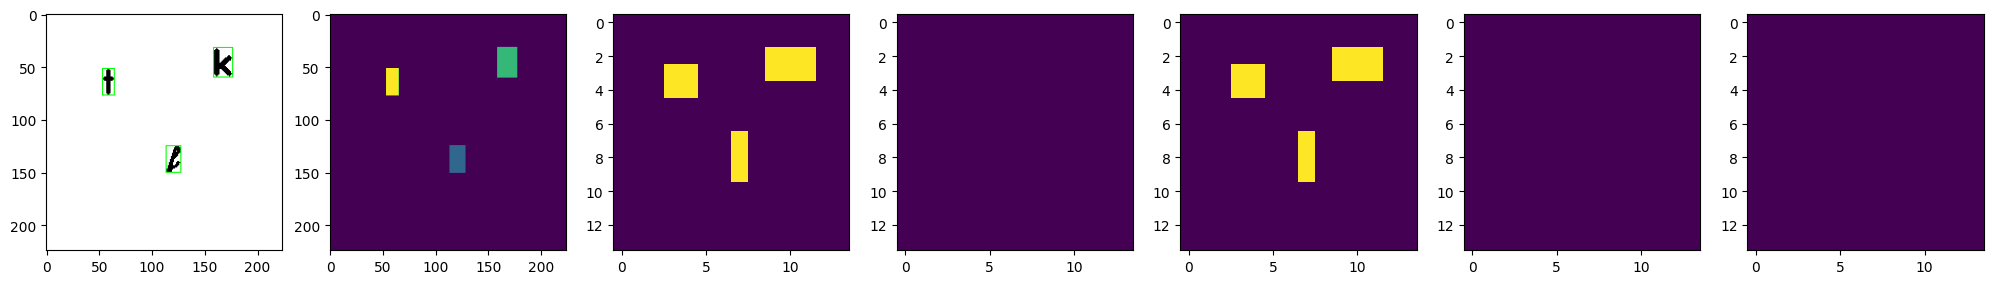

image (224, 224, 3)
segmentation (224, 224)
pixel_bbox_conf (14, 14)
pixel_bbox (14, 14, 4)
pixel_rbox_conf (14, 14)
pixel_rbox (14, 14, 4)
pixel_angle (14, 14, 1)


In [10]:
if __name__=='__main__':
    import matplotlib.pyplot as plt

    dataset = SimpleTextsDataset(
        num_real_time_samples=2, image_shape=(224, 224, 3), random_nums_texts=[3], min_len_text=1, max_len_text=1, min_max_fontScale=[0.5, 3], 
        # vocab=list('0123456789'),
        vocab=list('0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ'),
        # GRID_CELL_SIZE=32, dont_allow_text_overlap=True, min_angle=-180, max_angle=180,
        # GRID_CELL_SIZE=16, dont_allow_text_overlap=True, min_angle=-180, max_angle=180,
        GRID_CELL_SIZE=16, dont_allow_text_overlap=True, min_angle=-0, max_angle=0,
        NORMALIZE=True, REF_SCALE_XY=10.0, REF_SCALE_WH=10.0, REF_SCALE_ANGLE=180.0,
        # version=1,
        version=2,
        )

    s = dataset[0]
    sample = dataset.reverse_normalize(s)

    print(s['image'].shape, s['segmentation'].shape, s['pixel_bbox_conf'].shape, s['pixel_bbox'].shape, s['pixel_rbox_conf'].shape, s['pixel_rbox'].shape, s['pixel_angle'].shape)

    true_bboxes = [sample['pixel_bbox'][i,j] for h,w,_ in [sample['pixel_bbox'].shape] for i in range(h) for j in range(w) if sample['pixel_bbox_conf'][i,j] >= 0.5]
    img = draw_bboxes(sample['image'], true_bboxes=true_bboxes, box_format='xywh')
    true_rboxes = [sample['pixel_rbox'][i,j] for h,w,_ in [sample['pixel_rbox'].shape] for i in range(h) for j in range(w) if sample['pixel_rbox_conf'][i,j] >= 0.5]
    true_angles = [sample['pixel_angle'][i,j,0] for h,w,_ in [sample['pixel_angle'].shape] for i in range(h) for j in range(w) if sample['pixel_rbox_conf'][i,j] >= 0.5]
    img = draw_rboxes(img, true_rboxes=true_rboxes, true_angles=true_angles, box_format='xywh')

    plt.figure(figsize=(25,50))
    plt.subplot(1,7,1)
    plt.imshow(img)
    plt.subplot(1,7,2)
    plt.imshow(sample['segmentation'])
    plt.subplot(1,7,3)
    plt.imshow(sample['pixel_bbox_conf'])
    plt.subplot(1,7,4)
    plt.imshow(sample['pixel_bbox'][:,:,-1] != 0)
    plt.subplot(1,7,5)
    plt.imshow(sample['pixel_rbox_conf'])
    plt.subplot(1,7,6)
    plt.imshow(sample['pixel_rbox'][:,:,-1] != 0)
    plt.subplot(1,7,7)
    plt.imshow(sample['pixel_angle'][:,:,-1] != 0)
    plt.show()

    for k, v in sample.items():
        print(k, v.shape)